<div style="text-align: center;">
    <h1>Projekt: Wskazanie optymalnej lokalizacji farmy fotowoltaicznej, z wykorzystaniem analizy wielokryterialnej</h1>  
</div>

## 1. Cel projektu 
Celem projektu było wyznaczenie, bazując na wskazanych kryteriach, najlepszej lokalizacji inwestycji farmy fotowoltaicznej. Dodatkowo należało zaprojektować skrypt automatyzujący wybór obszaru najbardziej przydatnego pod wspomnianą wcześniej inwestycję w wybranej gminie. 

## 2.  Kryteria analizy oraz źródła wykorzystanych danych 
Wybór optymalnej lokalizacji farmy fotowoltaicznej, czyli takiej, która zapewni największą rentowność inwestycji jest procesem skomplikowanym i wymagającym wzięcia pod uwagę wielu czynników. W poniższej tabeli przedstawiono kryteria wykorzystane podczas wykonywania projektu. Jest to jednak tylko wybór przykładowych aspektów, skupiających się głównie wokół danych przestrzennych, spośród wszystkich, które należałoby rozważyć rzeczywiście planując podobną inwestycję. 

### Kryteria bazujące na danych zewnętrznych

| Lp. | Kryteria | Parametry | Źródło danych | Opis danych |
|-----|-----------|-----------|---------------|-------------|
| 1   | Odległość od rzek i zbiorników wodnych | Jak najbliżej; nieprzekraczalna strefa ochronna + bezpieczeństwo powyżej 100m | BDOT10k | Wektorowe warstwy modelujące rzeki i zbiorniki wodne |
| 2   | Odległość od budynków mieszkalnych | Jak najdalej, powyżej 150m | BDOT10k | Wektorowa warstwa modelująca zabudowę mieszkalną |
| 3   | Pokrycie terenu | Nie w lesie, powyżej 15m od lasu, optymalnie powyżej 100m od lasu | BDOT10k | Wektorowa warstwa modelująca obszary zalesione |
| 4   | Dostęp do dróg utwardzonych | Jak największe zagęszczenie | BDOT10k | Warstwa wektorowa modelująca sieć drogową |
| 5   | Nachylenie stoku | Optymalnie – płasko; maksymalnie 10% | NMT | Warstwa rastrowa NMT |
| 6   | Dostęp do światła słonecznego | Optymalny: stoki południowe (SW-SE) | NMT | Warstwa rastrowa NMT |
| 7   | Dobry dostęp do głównych dróg i węzłów komunikacyjnych | Najkrótszy czas podróży | OSM | Warstwa wektorowa z punktami przyjętymi jako główne węzły komunikacyjne |

### Kryteria bazujące na warstwach otrzymanych podczas analizy

| Lp. | Kryteria | Parametry | Źródło danych | Opis danych |
|-----|-----------|-----------|---------------|-------------|
| 1   | Próg przydatności terenu | 70% maks. przydatności | - | - |
| 2   | Przydatność działek | Minimum 50% działki na obszarze przydatnym | EGiB | Warstwa wektorowa modelująca działki |
| 3   | Minimalna powierzchnia i szerokość obszaru | Powierzchnia 2ha, Szerokość - 50m | - | - |
| 4   | Koszt podłączenia do sieci energetycznej | Najniższy możliwy na analizowanym obszarze | BDOT10k | Warstwa liniowa modelująca linie energetyczne |

Poza wyżej wymienionymi kryteriami, warto przy rzeczywistym planowaniu inwestycji w farmę fotowoltaiczną wziąć pod uwagę dodatkowe aspekty, m.in:
* Ceny gruntów na terenie gminy.
* Zgodność inwestycji z miejscowym planem zagospodarowania przestrzennego.
* Lokalizacja poza strefami ochrony przyrody i parkami krajobrazowymi.

## 3. Założenia wykonanej analizy 
W wyniku analizy wybierany jest obszar składający się z jednej lub więcej działek, który spełnia wszystkie kryteria przy zastosowanych progach przydatności oraz o najniższym koszcie przyłączenia do sieci energetycznej.W celu wykonania mapy przydatności, kryteria zostały podzielone ze względu na swoją charakterystykę, na kryteria ostre (podejście z zastosowaniem logiki Boola) i miękkie (podejście z zastosowaniem logiki rozmytej). Kryteria, które zostały potraktowane jako ostre: 
* Odległość obszaru od rzek i zbiorników wodnych musi być większa niż strefa ochronna wynosząca 100 metrów. 
* Odległość obszaru od budynków mieszkalnych musi wynieść przynajmniej 150 metrów. 
* Obszar musi znajdować się w odległości przynajmniej 15 metrów od lasów. 

Mapy przydatności powstają zgodnie z metodyką Weighted Linear Combination i z podziałem na metodę wagowania kryteriów miękkich: 
* Wagowanie równe - każde kryterium otrzymuje taką samą wagę.
* Wagowanie różne- każde kryterium otrzymuje wagę przydzielaną uznaniowo.

## 4. Opis skryptu realizującego ćwiczenie
Skrypt napisany został w języku Python, z wykorzystaniem biblioteki arcpy umożliwiającej dostęp do narzędzi geoprocessingu dostępnych w oprogramowaniu ArcGIS Pro. Podczas tworzenia skryptu został położony nacisk na jak największą automatyzację, minimalizację działań konfiguracyjnych, które musi wykonać użytkownik przed uruchomieniem i na to, aby mógł on zostać zaimplementowany jako narzędzie w aplikacji klienckiej ArcGIS Pro. Skrypt oparty jest w pełni na danych wprowadzanych przez użytkownika, przez co może być uruchomiony na danych dla dowolnie wybranej gminy w Polsce pod warunkiem wprowadzenia poprawnych danych. Przed uruchomieniem, należy przygotować bazę danych przestrzennych file Geodatabase w programie ArcGIS Pro i umieścić tam warstwy:
* warstwa poligonowa z granicami wybranej gminy
* warstwa działek dla powiatu/powiatów na terenie którego znajduje się wybrana gmina
* warstwa pokrycia terenu pochodzącą z bazy BDOT10k posiadająca kolumnę "X_KOD"
* raster czasu dojazdu do istotnych węzłów komunikacyjnych  - opis stworzenia takiej warstwy znajduje się w podpunkcie 7 rozdziału "Opis wykonania ćwiczenia"

Mając tak przygotowaną bazę danych, do uruchomienia skryptu potrzebne są następujące dane wejściowe (do uzupełnienia w funkcji main w dolnej części skryptu): 
* ścieżka do uprzednio stworzonej bazy danych file Geodatabase (Zmienna WORKSPACE)
* nazwa warstwy poligonowej granic gminy w bazie danych (Zmienna OBSZAR_INPUT)
* nazwa warstwy poligonowej z działkami w bazie danych (Zmienna DZIALKI_INPUT)
* nazwa warstwy poligonowej z pokryciem terenu w bazie danych (Zmienna PT_INPUT)
* ścieżki do folderów z danymi bdot dla dowolnej liczby powiatów (Zmienna DIRECTORIES)
* ścieżka do folderu z rastrami nmt pokrywającymi badany obszar (Zmienna RASTER_FOLDER_DIRECTORY)
* nazwę rastra czasu dojazdu w bazie danych (Zmienna TRAVELTIME_RASTER)

Po wprowadzeniu tych danych użytkownik musi jedynie uruchomić skrypt, który dokona obróbki i analizy danych oraz zwróci wynik, czyli warstwę zawierającą najbardziej przydatny pod budowę farmy fotowoltaicznej obszar. Organizacja skryptu opiera się na hierarchizacji funkcji analitycznych zlokalizowanych w funkcji main w dolnej części pliku, tak aby osoba sprawdzająca, bądź testująca skrypt, miała wgląd w kolejność wykonywanych zadań i mogła prześledzić działanie skryptu. Przekształcenie skryptu w narzędzie programu ArcGIS Pro, wymagałoby zmian kodu jedynie w 6 miejscach - ustawienie zmiennych wymienionych powyżej jako parametry narzędzia.

Dokładniejszy opis funkcjonalności skryptu wraz z fragmentami kodu znajduje się w następnym rozdziale sprawozdania. Funkcje obrabiające i przygotowujące dane zostały w tym opisie pominięte, jednak są dostępne do wglądu w załączonym pliku lub na repozytorium github*.

## 5. Opis wykonania ćwiczenia 
Analizowanym na potrzeby projektu obszarem była gmina Świeradów-Zdrój. Aby zapewnić jak najlepszą jakość informacji wynikowej, pod uwagę wzięto tereny bezpośrednio sąsiadujące z gminą (w promieniu 150 metrów). 
Analiza poszczególnych kryteriów dla gminy Świeradów-Zdrój: 

1. Odległość od rzek i zbiorników wodnych – jak najbliżej, poza nieprzekraczalną strefą ochronną 100 metrów 

    Charakterystyka kryterium wymusza, przy jego analizie, zastosowanie metodyki miękkiej i ostrej. Logika miękka realizuje zależność im bliżej do rzeki/zbiornika wodnego tym lepiej, natomiast logika ostra zapewnia zupełną nieprzydatność terenu znajdującego się w strefie ochronnej 100 metrów od rzek i zbiorników. 

    Przebieg analizy przydatności pod kątem kryterium: 

    * Zunifikowanie geometrii warstw sieci wodnej do poligonów. 

    * Stworzenie obrazu odległości euklidesowych przy użyciu narzędzia Euclidean Distance. Raster powstały wyniku działania tego narzędzia składa się z pikseli którym przypisana jest odległość do najbliższego obiektu warstwy sieci wodnej. 

    * Stworzenie obrazu przydatności według metodyki ostrej: 

    * Dla warstwy odległości euklidesowych, stworzenie obrazu zgodnie z metodyką rozmytą, stosując funkcję liniową o minimum 0 (metrów) i maksimum 100 (metrów). 

    * Reklasyfikacja obrazu, tak, aby wszystkie piksele o wartości innej niż 1 (odległości mniejszej niż 100 metrów) przyjęły wartość 0.    

    Funkcja generująca obraz przydatności dla kryterium:
    ```python
    def woda_criterium() -> None:
        distWoda = "EuCDist_clipped_SiecWodna"
        max_val = arcpy.management.GetRasterProperties(distWoda, "MAXIMUM").getOutput(0)
        strong = arcpy.sa.FuzzyMembership(distWoda, arcpy.sa.FuzzyLinear(0, 100))
        strong = arcpy.sa.Reclassify(strong, "Value", arcpy.sa.RemapRange([[0, 0.999, 0]]))
        strong.save("strong_woda")
        fuzzy = arcpy.sa.FuzzyMembership(distWoda, arcpy.sa.FuzzyLinear(max_val, 102))
        final = arcpy.sa.FuzzyOverlay([strong, fuzzy], "AND")
        final.save("fuzzy_siec_wodna")
    ```

2. Odległość od budynków mieszkalnych – jak najdalej, powyżej 150 metrów 

    To kryterium również wymaga analizy zgodnie z metodykami rozmytą i ostrą. W tym przypadku logika rozmyta realizuje założenie: im dalej od budynków mieszkalnych tym przydatność jest większa, natomiast logika ostra zapewnia, że obszary w odległości do 150 metrów od budynków mieszkalnych są uznawane za nieprzydatne. 
    Przebieg analizy przydatności pod kątem kryterium: 

    * Wyselekcjonowanie z warstwy wektorowej budynków (BUBD_A z bazy danych BDOT10k) warstwy budowli o przeznaczeniu mieszkalnym. 

    * Dla nowopowstałej warstwy stworzenie warstwy odległości euklidesowych. 

    * Stworzenie obrazu przydatności zgodnego z metodyką rozmytą, który otrzymujemy poprzez zastosowanie funkcji FuzzyMembership z funkcją liniową o minimum wynoszącym 150 metrów i maksimum wynoszącym maksymalną odległość pobraną z rastra odległości euklidesowych.

    * Obraz przydatności dla metodyki ostrej otrzymujemy reklasyfikując obraz metodyki miękkiej, nadpisując wartość 1 wszystkim pikselom, które nie są zerami (czyli są oddalone od budynków mieszkalnych o przynajmniej 152 metry).

    Funkcja generująca obrazy przydatności dla kryterium:
    ```python
    def budynki_criterium() -> None:
        distBudynki = "EuCDist_clipped_Budynki"
        max_val = arcpy.management.GetRasterProperties(distBudynki, "MAXIMUM").getOutput(0)
        fuzzy = arcpy.sa.FuzzyMembership(distBudynki, arcpy.sa.FuzzyLinear(152, max_val))
        strong_budynki = arcpy.sa.Reclassify(fuzzy, "Value", arcpy.sa.RemapRange([[0.001, 1, 1]]))
        strong_budynki.save("strong_budynki")
        fuzzy.save("fuzzy_budynki")
    ```

3. Pokrycie terenu – odległość od lasu powyżej 15 metrów, optymalnie powyżej 100 metrów

    Kryterium swoją treścią wymusza zastosowanie do jego realizacji metodyki ostrej i rozmytej. Kryterium ostrym w tym przypadku jest odległość od lasu wynosząca przynajmniej 15 metrów, stosując logikę ostrą dla tego fragmentu kryterium minimalizujemy wpływ cieni rzucanych przez drzewa na wydajność inwestycji. Kryterium miękkie gwarantuje liniowo rosnącą przydatność w przedziale 15 - 100 metrów i przydatność maksymalną powyżej 100 metrów. 
    Przebieg analizy przydatności pod kątem kryterium: 

    * Stworzenie warstwy odległości euklidesowych dla warstwy wektorowej lasów. 

    * Wygenerowanie obrazu przydatności logiką ostrą: 

    * Stworzenie przy użyciu narzędzia FuzzyMembership obraz przydatności zgodny z metodyką miękką, stosując funkcję liniową o minimum równym 0 metrów i maksimum równym 15 metrów. 

    * Reklasyfikacja uprzednio powstałej warstwy, nadpisując wszystkim wartościom innym niż 1 wartości 0 – wszystkie obszary w odległości do 15 metrów od lasów otrzymują zerową przydatność. 

    * Wygenerowanie obrazu przydatności logiką rozmytą używając narzędzia FuzzyMembership z funkcją liniową o minimum równym 17 metrów i maksimum równym 100 metrów. 

    Funkcja generująca obrazy przydatności dla kryterium:
    ```python
    def lasy_criterium() -> None:
        distLasy = "EuCDist_clipped_Lasy"
        strong = arcpy.sa.FuzzyMembership(distLasy, arcpy.sa.FuzzyLinear(0, 15))
        strong = arcpy.sa.Reclassify(strong, "Value", arcpy.sa.RemapRange([[0, 0.999, 0]]))
        strong.save("strong_lasy")
        fuzzy = arcpy.sa.FuzzyMembership(distLasy, arcpy.sa.FuzzyLinear(17, 100))
        final = arcpy.sa.FuzzyOverlay([strong, fuzzy], "AND")
        final.save("fuzzy_lasy")

    ```

4. Dostęp do dróg utwardzonych – jak największe zagęszczenie

    Przebieg analizy przydatności pod kątem kryterium:
    * Stworzenie rastra gęstości sieci drogowej w przeliczeniu na jednostkę powierzchni (przyjęto kilometry kw.) przy użyciu narzędzia LineDensity na warstwie dróg. 
    * Wygenerowanie obrazu przydatności na podstawie rastra gęstości sieci, zgodnie z metodyką rozmytą przy użyciu narzędzia FuzzyMembership z funkcją liniową o minimum równym 0 i maksimum równym wartości maksymalnej pobranej z warstwy gęstości dróg. 

    Funkcja generująca obraz przydatności dla kryterium:
    ```python
    def drogi_criterium() -> None:
        drogi = "clipped_SiecDrogowa"
        density = arcpy.sa.LineDensity(drogi, None, cell_size=5, area_unit_scale_factor="SQUARE_KILOMETERS")
        maxVal = arcpy.management.GetRasterProperties(density, "MAXIMUM").getOutput(0)
        fuzz = arcpy.sa.FuzzyMembership(density, arcpy.sa.FuzzyLinear(0, maxVal))
        fuzz.save("fuzzy_siec_drogowa")
    ```

5. Nachylenie stoków - im mniejsze tym lepiej, do 10% 

    Przebieg analizy przydatności pod kątem kryterium: 
    * Wygenerowanie mapy spadków na podstawie numerycznego modelu terenu. 

    * Stworzenie obrazu przydatności zgodnie z metodyką rozmytą (funkcja FuzzyMembership) stosując funkcję liniową. Za minimum funkcja przyjmuje arbitralnie przyjętą największą wartość kątową, dla której dany piksel jest idealnie przydatny (przyjęto 5% nachylenia), a za maksimum 0 (% nachylenia). 

    * Reklasyfikacja uprzednio otrzymanego obrazu, nadając wszystkim pikselom o wartości 0%-5% wartości (przydatności) 1. (Obraz nr 1) 

    * Stworzenie kolejnego obrazu przydatności stosując funkcję FuzzyMembership na podstawie mapy spadków. Ponownie użycie funkcji liniowej, tym razem za minimum przyjmując 10 (% nachylenia), a za maksimum 0 (% nachylenia). W ten sposób otrzymujemy obraz, w którym wszystkie piksele o nachyleniu większym niż 10 % otrzymują wartość 0, natomiast przydatność rośnie od 10% w kierunku 0%. (Obraz nr 2) 

    * Wygenerowanie ostatecznej mapy przydatności dla tego kryterium poprzez połączenie logiką “OR” obrazu nr 1 i obrazu nr 2 (funkcja FuzzyOverlay). 

    Funkcja generująca obraz przydatności dla kryterium:
    ```python
    def slope_criterium() -> None:
        slope = "slope_p"
        fuzz = arcpy.sa.FuzzyMembership(slope, arcpy.sa.FuzzyLinear(5, 0))
        fuzz = arcpy.sa.Reclassify(fuzz, "Value", arcpy.sa.RemapRange([[0.00001, 1, 1]]))
        fuzz_2 = arcpy.sa.FuzzyMembership(slope, arcpy.sa.FuzzyLinear(10, 0))
        fin = arcpy.sa.FuzzyOverlay([fuzz, fuzz_2], "OR")
        fin.save("fuzzy_slope")
    ```

6. Dostęp do światła słonecznego - optymalnie stoki południowe 

    Przebieg analizy przydatności pod kątem kryterium: 
    * Wygenerowanie mapy orientacji nachylenia stoków - funkcja Aspect. 

    * Reklasyfikacja otrzymanej mapy nadając wartość 1 pikselom o wartości znajdującej się w przedziałach kątów azymutalnych odpowiadających stokom południowym, południowo-zachodnich, południowo-wschodnich: 
        * ⟨−1⟩
        * ⟨112.5, 247.5⟩
        I wartości 0 pikselom o wartościach z przedziałów: 
        * ⟨0, 112.5⟩
        * ⟨247.5, 360⟩
        
    W przypadku tego kryterium do wykonania mapy przydatności wykorzystano metodykę ostrą, pomimo faktu, iż w na etapie tworzenia zbiorczej mapy przydatności, nie jest traktowane jako kryterium ostre. Takie podejście uzasadnione jest tym, iż kierunek nachylenia stoku jest czynnikiem, nie koniecznym, ale bardzo istotnym z perspektywy rentowności inwestycji jaką jest farma fotowoltaiczna. Farma zlokalizowana na stoku o optymalnej orientacji może zapewniać wydajność energetyczną wyższą o nawet 30%**, stąd choć kryterium traktowane jest jako miękkie, poprzez nadanie przydatności 1 lub zero, będzie miało duży wpływ na ostateczną (zbiorczą) przydatność na terenie wybranej gminy. 

    Funkcja generująca obraz przydatności dla kryterium:
    ```python
    def aspect_criterium() -> None:
        aspect = "aspect_p"
        remap = arcpy.sa.RemapRange([[-1, -1, 1], [0, 112.5, 0], [112.5, 247.5, 1], [247.5, 360, 0]])
        reclassified = arcpy.sa.Reclassify(aspect, "Value", remap)
        reclassified.save("fuzzy_aspect")
    ```

7. Jak najkrótszy dojazd do istotnych drogowych węzłów komunikacyjnych 

    Przebieg analizy przydatności pod kątem kryterium: 

    * Wybór punktów odpowiadających istotnym drogowym węzłom komunikacyjnym. Dla gminy Świeradów-Zdrój wybranych zostało 16 punktów, zlokalizowanych na odcinku Jelenia Góra - Lubań drogi krajowej nr 30. Są to punkty, w których występuje skrzyżowanie wspomnianej drogi z drogami, którymi można dojechać do drogi krajowej nr 30 ze Świeradowa-Zdroju. 

    * Wygenerowanie obrazu czasu dojazdu do węzłów komunikacyjnych. Czynność ta wykonywana jest przy użyciu wtyczki QNEAT3 progrmu QGIS, która oferuje funkcje przydatne przy analizach sieciowych. Wynikowy obraz składa się z pikseli, których wartość zależna jest od czasu dojazdu do punktów wybranych jako dane wejściowe dla wtyczki – w badanym przypadku, punktów reprezentujących istotne węzły komunikacyjne. Ważne jest odpowiednie dopasowanie zasięgu obliczeń w menu narzędzia QNEAT, tak aby ogarniał on jak największą część obszaru opracowania (tu obszaru gminy). 

    * Pobranie maksymalnej i minimalnej wartości z rastra czasu dojazdu do węzłów komunikacyjnych. 

    * Przypisanie pikselom o wartościach 0 (No Data), wartości maksymalnej pobranej w poprzednim punkcie. 

    * Wygenerowanie obrazu przydatności dla kryterium, stosując metodykę rozmytą z funkcją liniową o minimum równemu wartości maksymalnej pobranej z rastra oraz maksimum równemu wartości minimalnej. 

    Funkcja generująca obraz przydatności dla kryterium:
    ```python
    def distance_criterium(distanceToTransportLinksRaster: str, obszar: str) -> None:
        clipped = arcpy.ia.Clip(distanceToTransportLinksRaster, obszar)
        clipped.save("clipped_trans_dist")
        maxVal = int(arcpy.management.GetRasterProperties("clipped_trans_dist", "MAXIMUM").getOutput(0))
        minVal = get_min_from_raster("clipped_trans_dist")
        reclass = arcpy.sa.Reclassify("clipped_trans_dist", "Value", arcpy.sa.RemapRange([[-1, 0, maxVal]]))
        reclass.save("proba")
        final = arcpy.sa.FuzzyMembership(reclass, arcpy.sa.FuzzyLinear(maxVal, minVal))
        final.save("fuzzy_transport_links")
    ``` 

Połączenie wyżej wymienionych kryteriów w zbiorczą mapę przydatności dla gminy Świeradów-Zdrój: 

Specyfika projektu zakładała finalne wygenerowanie dwóch map przydatności: stosującej równe wagi kryteriów miękkich i stosującej różne nadane arbitralnie wagi kryteriów miękkich. 
W drugim przypadku zastosowano następujące wagi: 
| Kryterium                               | Waga |
|-----------------------------------------|------|
| Odległość od rzek i zbiorników wodnych  | 0.15 |
| Odległość od budynków mieszkalnych      | 0.15 |
| Pokrycie Terenu                         | 0.20 |
| Dostęp do dróg utwardzonych             | 0.20 |
| Nachylenie stoków                       | 0.10 |
| Dostęp do światła słonecznego           | 0.15 |
| Dojazd do istotnych węzłów komunikacyjnych | 0.05 |

Kryteria miękkie zostały połączone z ostrymi zgodnie z wzorem na Weighted Linear Combination: 
$$P = \sum w_i X_i \cdot \prod C_j$$ 
Gdzie: 
<br>P - przydatność całkowita <br>
$X_{i}$ - kryterium miękkie <br>
$C_{j}$ - kryteria ostre wyrażone w jednym obrazie <br>
$\prod$ - symbol iloczynu

W środowisku arcpy, do wygenerowanie nieznormalizowanych map przydatności użyto kombinacji funkcji Weighted Sum i Times.  
Ostateczne mapy przydatności otrzymywane są poprzez przyjęcie progu przydatności równego 70% maksymalnej przydatności nieznormalizowanej i nadanie odpowiednio wartości 0 pikselom mającym wartość poniżej progu i 1 pikselom powyżej progu.

Funkcja generująca obrazy całkowitej przydatności obszaru gminy:
```python
def get_final_map(weighted: str) -> None:
    allFuzzy = arcpy.ListRasters("fuzzy*")
    PROG = 0.7
    if weighted == "weighted":
        weights = {
        "fuzzy_siec_wodna": 0.15,
        "fuzzy_siec_drogowa": 0.20,
        "fuzzy_lasy": 0.20,
        "fuzzy_budynki": 0.15,
        "fuzzy_slope": 0.10,
        "fuzzy_transport_links": 0.05,
        "fuzzy_aspect": 0.15
        }
    elif weighted == "unweighted":
        weights = {
            "fuzzy_siec_wodna": 1/7,
            "fuzzy_siec_drogowa": 1/7,
            "fuzzy_lasy": 1/7,
            "fuzzy_budynki": 1/7,
            "fuzzy_slope": 1/7,
            "fuzzy_transport_links": 1/7,
            "fuzzy_aspect": 1/7
        }
    raster_weight_list = get_raster_weights(allFuzzy, weights)
    ws_tbl = arcpy.sa.WSTable(raster_weight_list)   
    weighted_sum = arcpy.sa.WeightedSum(ws_tbl) 
    weighted_sum.save(f"fuzzy_all_{weighted}")

    not_normalized_wlc = arcpy.sa.Times(f"fuzzy_all_{weighted}", "strong_all")
    not_normalized_wlc.save(f"not_normalized_wlc_{weighted}")

    maxval = arcpy.management.GetRasterProperties(f"not_normalized_wlc_{weighted}", "MAXIMUM").getOutput(0)
    maxval = float(maxval.replace(',', '.'))

    border = maxval * PROG
    reclass = arcpy.sa.Reclassify(
        f"not_normalized_wlc_{weighted}", 
        "Value", 
        arcpy.sa.RemapRange([[0, border, 0], [border, maxval, 1]])
    )
    reclass.save(f"final_mapp_{weighted}")
```
Porównanie otrzymanych map przydatności:

* Mapa przydatności z równym wagowaniem kryteriów miękkich:<br>
    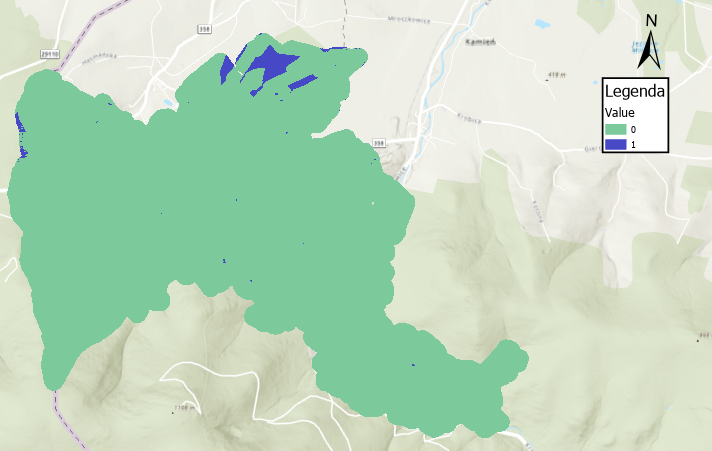

* Mapa przydatności z uznaniowym wagowaniem kryteriów miękkich:<br>
    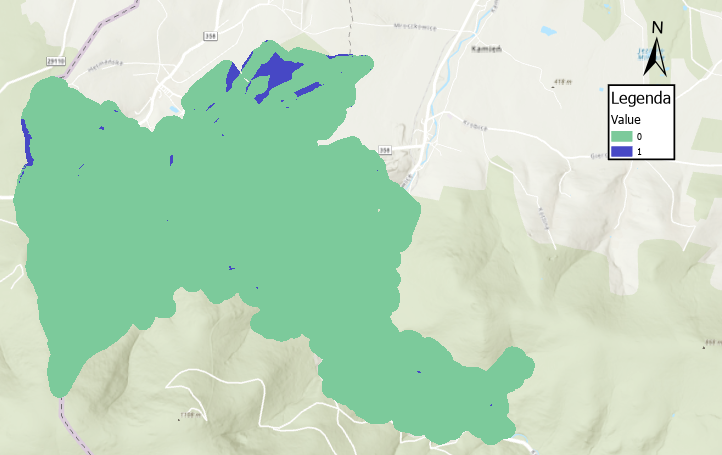

Dla gminy Świeradów-Zdrój, występują bardzo niewielkie różnice między mapami przydatności.

Kolejnym krokiem analizy był wybór działek na badanym terenie, na podstawie tego jaki procent ich powierzchni jest terenem przydatnym pod lokalizację farmy fotowoltaicznej. Przyjęty został próg 50%, ze względu na stosunkowo niewielką liczbę obszarów przydatnych w Świeradowie-Zdroju. Selekcja działek odbyła się według następującego schematu:
* 1. Stworzenie kopii mapy przydatności(wagowanej i niewagowanej) i przypisanie pikselom nieprzydatnym (o wartościach 0) wartości NoData.
* 2. Wektoryzacja rastra zawierającego jedynie piksele o wartościach 1 do postaci poligonowej.
* 3. Zsumowanie powierzchni poligonów przydatności wewnątrz działek - narzędzie SummarizeWithin.
* 4. Użycie narzędzia MakeFeatureLayer do stworzenia warstwy działek wewnątrz których spełniony jest warunek powierzchnia obsz. przyd. >= 50% powierzchni działki.

Funkcja realizująca selekcję działek:
```python
def select_dzialki(weighted: str) -> None:
    final_map = f"final_mapp_{weighted}"
    dzialki = "dzialki_s"
    set_null_result = arcpy.sa.SetNull(final_map, final_map, "VALUE = 0")
    useful_polygons = arcpy.conversion.RasterToPolygon(
        set_null_result, 
        f"polygons_rasterized_{weighted}", 
        "NO_SIMPLIFY"
    )
    summarized = arcpy.analysis.SummarizeWithin(
        in_polygons=dzialki,
        in_sum_features=useful_polygons,
        out_feature_class=f"summarized_in_dzialki_{weighted}", 
        keep_all_polygons="ONLY_INTERSECTING", 
        sum_fields="Shape_Area Sum", 
        sum_shape="ADD_SHAPE_SUM", 
        shape_unit="SQUAREMETERS", 
        group_field=None,
        add_min_maj="NO_MIN_MAJ", 
        add_group_percent="NO_PERCENT", 
        out_group_table=None
    )
    layer = arcpy.management.MakeFeatureLayer(
        in_features=summarized, 
        out_layer=f"useful_dzialki_{weighted}", 
        where_clause="sum_Shape_Area >= Shape_Area * 0.5"
    )
    arcpy.conversion.FeatureClassToGeodatabase(layer, WORKSPACE)

```


W tak wyselekcjonowanych działkach znajdujemy te, które ze sobą sąsiadują i łączymy je w jeden obiekt (narzędzie Dissolve). Dla tak przygotowanych obszarów przeprowadzić musimy analizę spełnienia warunku: powierzchnia obszaru musi wynosić przynajmniej 2 hektary, a jego szerokość przynajmniej 50 metrów. Schemat działania:

* 1. Stworzenie warstwy ściśle przylegających prostokątnych ramek ograniczających dla każdego z obszarów powstałych z połaczenia działek (narzędzie MinimumBoundingGeometry).
* 2. Dodanie do nowopowstałej warstwy pola do zapisywania szerokości.
* 3. Dla każdej ramki ograniczającej obliczenie i wybór najkrótszego boku - minimalnej szerokości i zapisanie jej w polu szerokość.
* 4. stworzenie nowej, finalnej warstwy działek, które spełniają warunek powierzchni i szerokości.

Funkcja, która tworzy obszary i wybiera te, które spełniają warunki powierzchni i szerokości:

```python
def select_obszar(weighted: str) -> None:
    select_dzialki(weighted)
    dzialki_gdb = arcpy.ListFeatureClasses(f"useful_dzialki_{weighted}")[0]
    dzialki_dissolved = arcpy.management.Dissolve(
        dzialki_gdb, 
        f"dzialki_dissolved_{weighted}", 
        None, 
        None, 
        "SINGLE_PART", 
        None
    )
    bbox_layer = arcpy.management.MinimumBoundingGeometry(
        dzialki_dissolved, 
        f"bbox_{weighted}", 
        "RECTANGLE_BY_WIDTH"
    )
    arcpy.management.AddField(bbox_layer, "width", "DOUBLE")

    with arcpy.da.UpdateCursor(bbox_layer, ["SHAPE@", "width"]) as cursor:
        for row in cursor:
            polygon = row[0]
            vertices = [point for point in polygon.getPart(0)]
            if len(vertices) >= 4:
                side_lengths = [
                    distance_between_points(vertices[0], vertices[1]),
                    distance_between_points(vertices[1], vertices[2]),
                    distance_between_points(vertices[2], vertices[3]),
                    distance_between_points(vertices[3], vertices[0])
                ]
                row[1] = min(side_lengths)
            cursor.updateRow(row)
            
    arcpy.management.JoinField(dzialki_dissolved, "OBJECTID", bbox_layer, "OBJECTID", "width")
    final = arcpy.management.MakeFeatureLayer(
        in_features=f"dzialki_dissolved_{weighted}",
        out_layer=f"dzialki_final_{weighted}",
        where_clause="Shape_Area >= 20000 And width >= 50"
    )
    arcpy.conversion.FeatureClassToGeodatabase(final, WORKSPACE)
```

Przy przyjętych założeniach dla obu map przydatności otrzymujemy ten sam obszar spełniający kryteria:
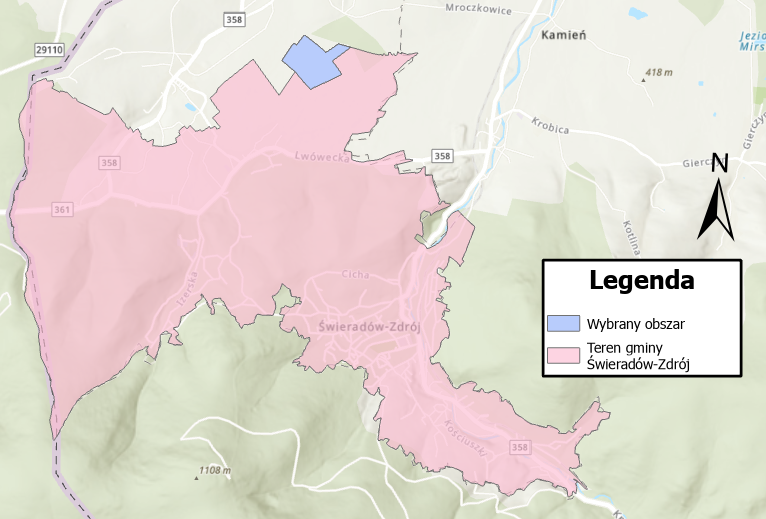


Kolejnnym krokiem było wyznaczenie najlepszego, pod względem kosztów, miejsca przyłączenia wybranego obszaru do sieci energetycznej. W tym celu wykonujemy następujące czynności:
* 1. Dodanie do warstwy pokrycia terenu pola do przechowywania kosztów wyliczonych na podstawie kolumny "X_KOD". 
* 2. Wygenerowanie mapy kosztów względnych poprzez rasteryzację ze względu na pole przechowujące wcześniej wygenerowane koszty.
* 3. Wykorzystanie narzędzia DistanceAccumulation w celu wytworzenia map kosztów skumulowanych i map kierunków dla wariantów o różnych i równych wagach.
* 4. Utworzenie ścieżki przyłącza przy użyciu narędzia CostPath z ustawieniem "BEST_SINGLE", które gwarantuje wybranie jednego, najlepszego wariantu przyłącza.

Na koniec następuje wyselekcjonowanie obszaru, spośród wcześniej wybranych, na terenie którego znajduje się punkt najbardziej optymalnego przyłączenia do sieci. Wykorzystano do tego celu narzędzie Select Layer By Location, które wyselekcjonowało obszar mający styczność z wyznaczonym najlepszym przyłączem do sieci energetycznej.

Zestaw funkcji realizujący wyżej wymienione kroki:

```python
def get_costraster_pt():
    pt = calculate_field_pt()
    arcpy.conversion.FeatureToRaster(pt, "koszt", "cost_raster_pt", 5)

def get_costmap_pt(weighted: str):
    cost_raster = "cost_raster_pt"
    set_null_result = arcpy.sa.SetNull(cost_raster, cost_raster, "VALUE = 0")
    cost_distance = arcpy.sa.DistanceAccumulation(
        in_source_data=f"dzialki_final_{weighted}", 
        in_cost_raster=set_null_result, 
        out_back_direction_raster=f"backlink_raster_pt_{weighted}"
    )
    cost_distance.save(f"cost_distance_pt_{weighted}")

def get_dzialka_naj(weighted: str):
    cost_distance = f"cost_distance_pt_{weighted}"
    backlink = f"backlink_raster_pt_{weighted}"
    siec_energetyczna = "clipped_SiecEnergetyczna"
    cost_path = arcpy.sa.CostPath(
        in_destination_data=siec_energetyczna,
        in_cost_distance_raster=cost_distance,
        in_cost_backlink_raster=backlink,
        path_type="BEST_SINGLE",
        destination_field="OBJECTID",
        force_flow_direction_convention="INPUT_RANGE"
    )
    cost_path.save(f"cost_path_energetic_{weighted}")
    arcpy.conversion.RasterToPolyline(cost_path, "przylacze", "ZERO")
    selected_obszar = arcpy.management.SelectLayerByLocation(
        in_layer=f"dzialki_final_{weighted}",
        overlap_type="INTERSECT",
        select_features="przylacze",
        search_distance=None,
        selection_type="NEW_SELECTION",
        invert_spatial_relationship="NOT_INVERT"
    )
    arcpy.conversion.FeatureClassToGeodatabase(selected_obszar, WORKSPACE)
```
Jak już wspomniano wyżej dla obu wariantów w gminie Świeradów-Zdrój otrzymano ten sam obszar stąd, jest on również traktowany jako obszar, który najtaniej jest przyłączyć do sieci energetycznej:
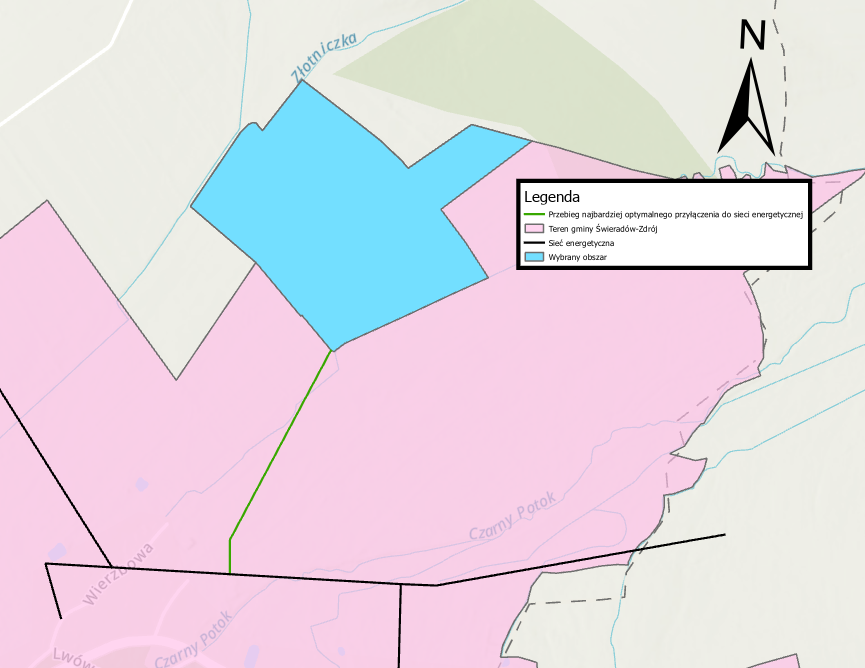

## 6. Pomysł ulepszenia obecnego schematu postępowania
W celu zapewnienia jeszcze bardziej miarodajnych wyników analizy lokalizacji farmy fotowoltaicznej, można uwzględnić dodatkowe kryterium: odległość potencjalnej inwestycji od terenów ochrony przyrody tj. parków krajobrazowych, narodowych, rezerwatów i obszarów Natura 2000. Budowa farmy fotowoltaicznej na terenie lub w pobliżu tych obszarów, przedewszystkim przyczyniłaby się do zniszczeń środowiska naturalnego i znacznego obniżenia ich walorów estetycznych.
Uważam, że treść odpowiedniego kryterium mogłaby brzmieć:
"Obszar musi znajdować się jak najdalej, w odległości przynajmniej 100 metrów od naturalnych terenów chronionych" 
W celu analizy jego spełnienia, można skorzystać z klasy TC (tereny chronione) z bazy BDOT10K, a schemat działania bardzo przypominałby ten opisany w podpunkcie 1 rozdziału "Opis wykonania ćwiczenia".

## 7. Raport z testu wykonania modelu na danych z innego obszaru. 

Do testów użyto danych odpowiednich dla gminy Pleśnia w powiecie Tarnowskim. Skrypt realizujący model zakończył działanie bez zgłaszania błędów i zwrócił zgodnie z oczekiwaniem, obszar najlepiej spełniający opisane w tym sprawozdaniu kryteria w dwóch wariantach. W przypadku tego obszatu testowego również otrzymujemy bardzo zbliżone mapy przydatności całościwej:

Mapa przydatności z zastosowanym różnym wagowaniem kryteriów miękkich:
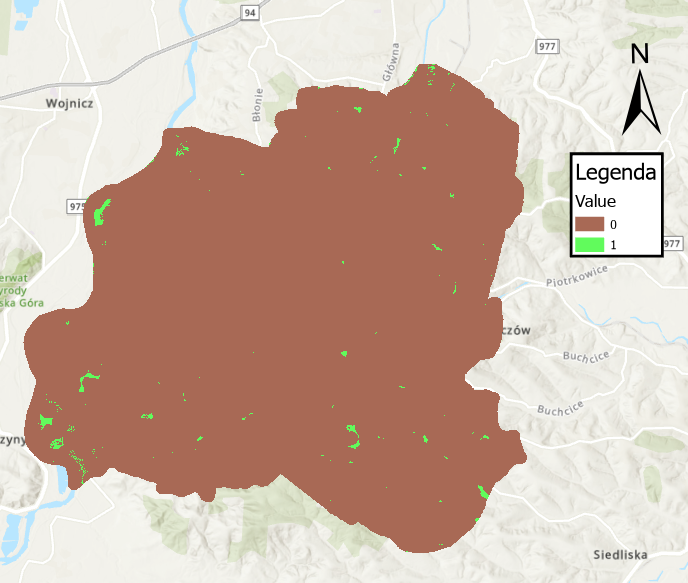

Mapa przydatności z zastosowanym równym wagowaniem kryteriów miękkich:
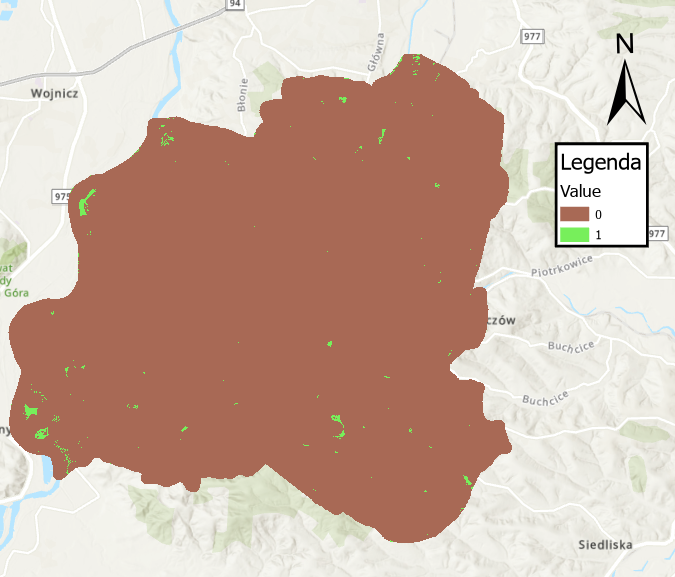

W odróżnieniu do gminy Świeradów zdrój, algorytm wyselekcjonował w gminie Pleśnia dwa obszary spełniające kryteria poprzedzające koszt przyłączenia do sieci energetycznej, jednak ponownie bez względu na wagowanie kryteriów miękkich otrzymujemy te same obszary przy wykorzystaniu obydwu map przydatności:

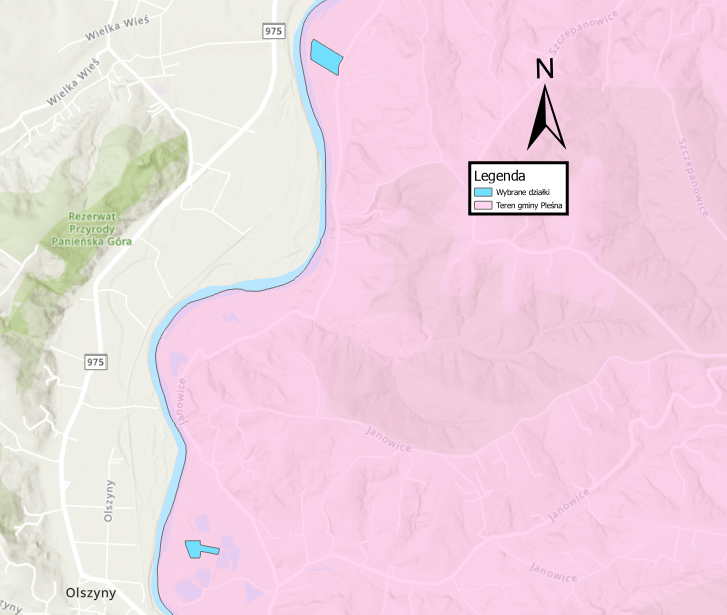

Ostatecznie wybrana zostaje działka, którą najtaniej jest podłączyć do sieci energetycznej i generowany jest schemat przebiegu najbardziej optymalnego połączenia z siecią:

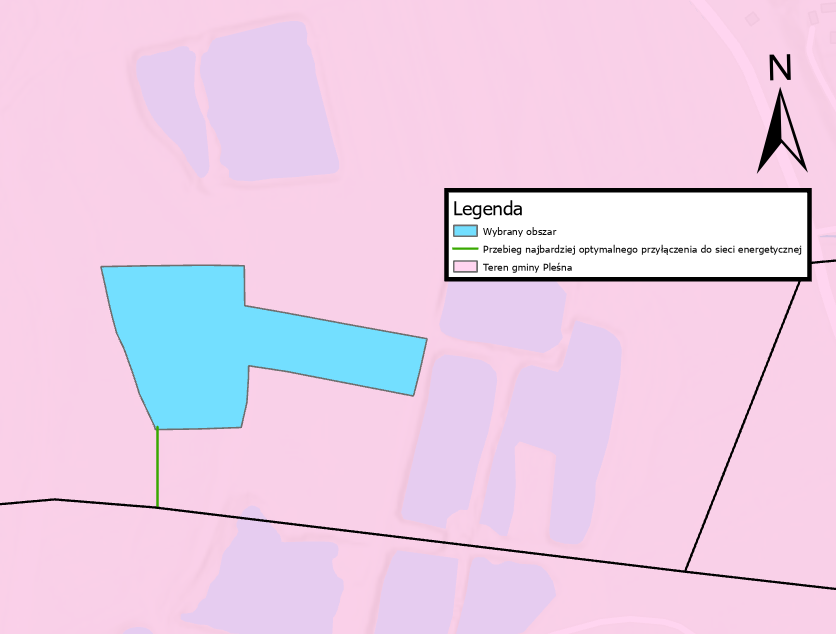

## 8. Podsumowanie


* 1. Skrypt zaproponowany jako rozwiązanie problemu projektowego nie jest idealny. Dwie główne wady mojego rozwiązania to długi czas wykonywania całości skryptu (nawet ok. 8 minut) oraz powstające w bazie danych, przy wielokrotnym uruchamianiu skryptu,  duplikaty warstwy rzek (warstwy z końcówką "_polygon"), co nie ma wpływu na działanie skryptu, ale może prowadzić do nieznacznego zaśmiecania bazy danych. 
* 2. Dla obydwu obszarów testowych skrypt wyselekcjonował na podstawie map przydatności maksymalnie dwa obszary przydatne pod budowę farmy fotowoltaicznej. Tak wąski wybór oznacza wprost, iż żadna z badanych gmin nie jest idealnym terenem pod realizację takiej inwestycji (przynajmniej przy obecnie przyjętych kryteriach). W przypadku obydwu gmin, kryteria ostre determinują nieprzydatność większości ich terytorium, co naturalnie przekłada się na zmniejszenie, a nawet zminimalzowanie znaczenia kryteriów miękkich, z czego w oczywisty sposób wynikają małe różnice w mapach przydatności, pomimo dwóch wariantów wagowania kryteriów miękkich.

    Mapa przydatności gminy Pleśna pod kątem spełnienia kryteriów ostrych:
    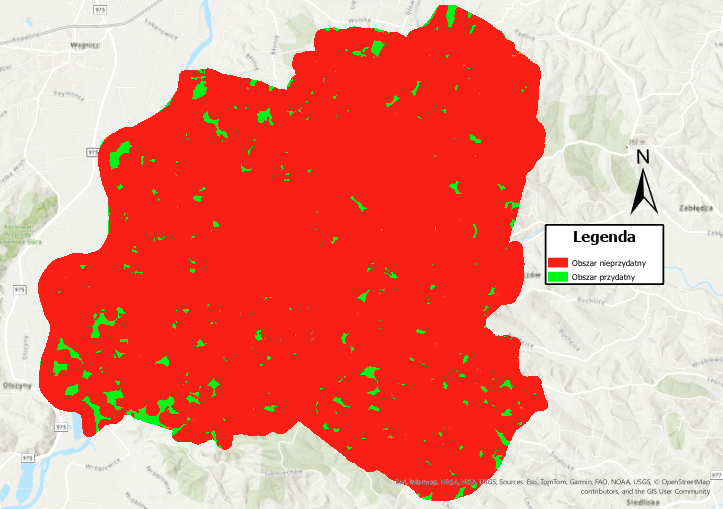

    Mapa przydatności gminy Świeradów-Zdrój pod katem spełnienia kryteriów ostrych:
    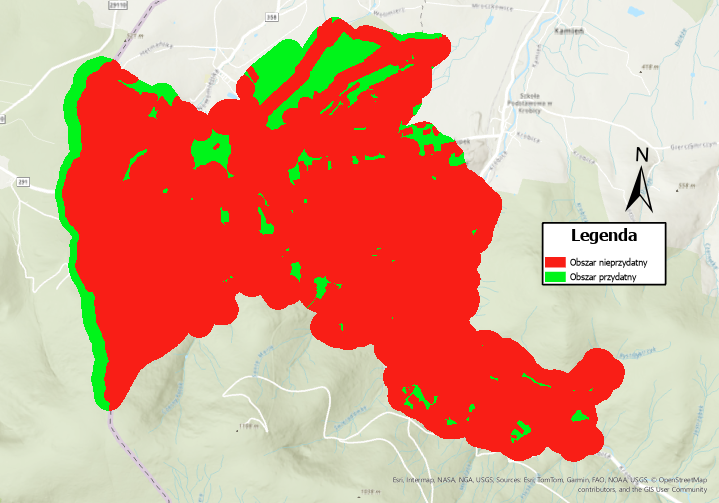


*https://github.com/fszafran/analizy-fotowoltaika/blob/master/main.py <br>
**https://www.sunrun.com/knowledge-center/best-direction-for-solar-panels 